# California Housing Price Prediction Using Multiple Linear Regression

In this project, we will build a Multiple Linear Regression model to predict median house values using different features from the California Housing dataset.

## Project Objective

The objective of this project is to:

- Explore and understand the California Housing dataset.
- Perform basic data cleaning and preprocessing.
- Analyze relationships between the features and the target variable.
- Build a Multiple Linear Regression model.
- Generate predictions for house values.
- Evaluate the model using R² and RMSE.
- Visualize the actual and predicted house values.

## Step 1: Setup and Explore Data

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1. Load Data:

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2. Data Information:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### 3. Statistical summary:

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 2: Check for Missing Values

In [5]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## Step 3: Check for Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

#Step 4: Check for Outliers

## Step 4: Boxplots and Potential Outliers

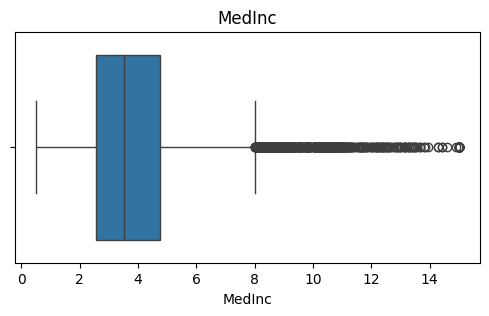

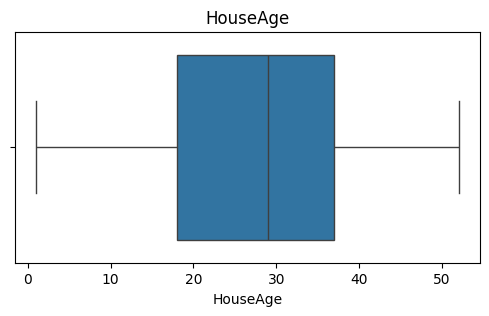

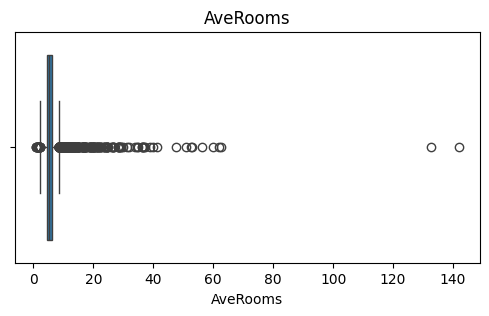

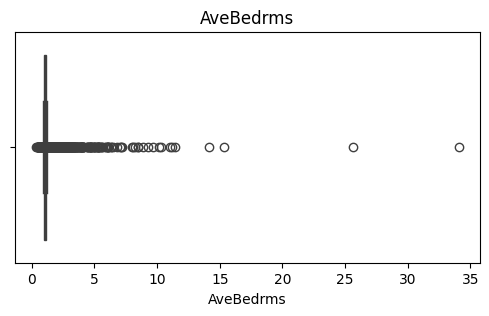

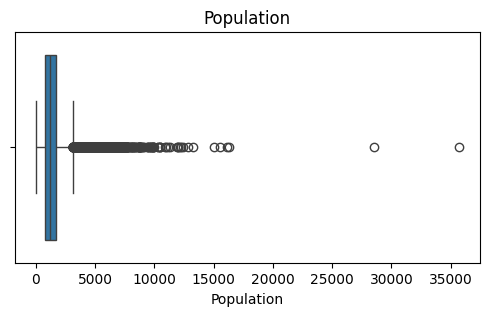

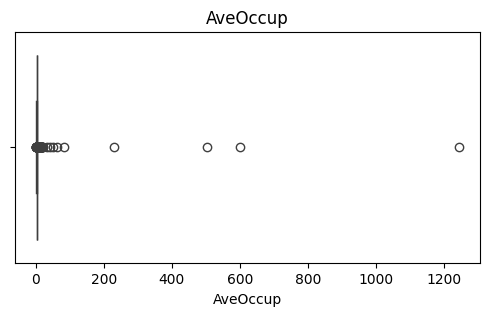

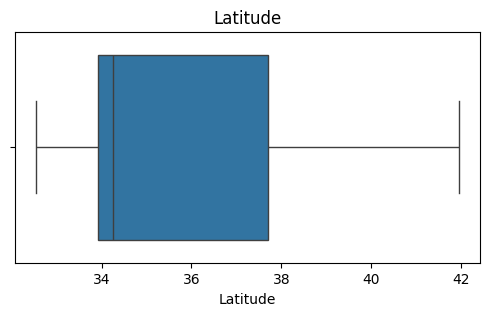

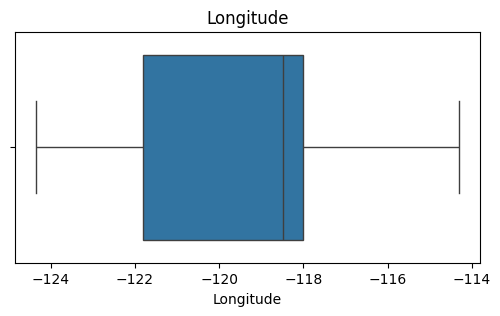

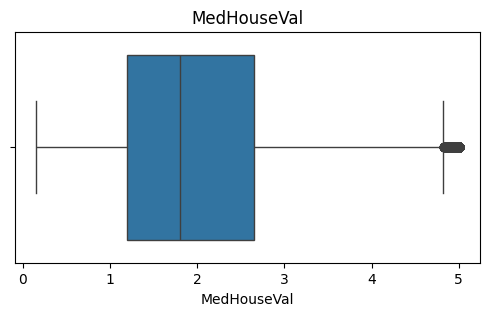

In [8]:
for col in df.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Insights
- Boxplots reveal the median, interquartile range, spread, and potential outliers.
- Noticeable extreme observations are present in variables such as `AveRooms`, `AveBedrms`, `Population`, and `AveOccup`.
- These observations should not automatically be deleted because they may represent real districts. They should first be investigated.

#Step 5: Handle Outliers

In [9]:
outlier_cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

print("Shape before handling the outliers:", df.shape)
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

print(df[outlier_cols].describe())

print("Shape after handling the outliers:", df.shape)

Shape before handling the outliers: (20640, 9)
           AveRooms     AveBedrms    Population      AveOccup
count  20640.000000  20640.000000  20640.000000  20640.000000
mean       5.304740      1.057958   1336.959012      2.899647
std        1.246177      0.080448    765.550830      0.691142
min        2.023219      0.865909      3.000000      1.150961
25%        4.440716      1.006079    787.000000      2.429741
50%        5.229129      1.048780   1166.000000      2.818116
75%        6.052381      1.099526   1725.000000      3.282261
max        8.469878      1.239697   3132.000000      4.561041
Shape after handling the outliers: (20640, 9)


In [10]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

#Step 7: Check Correlations

## Step 5: EDA

### Correlation Matrix

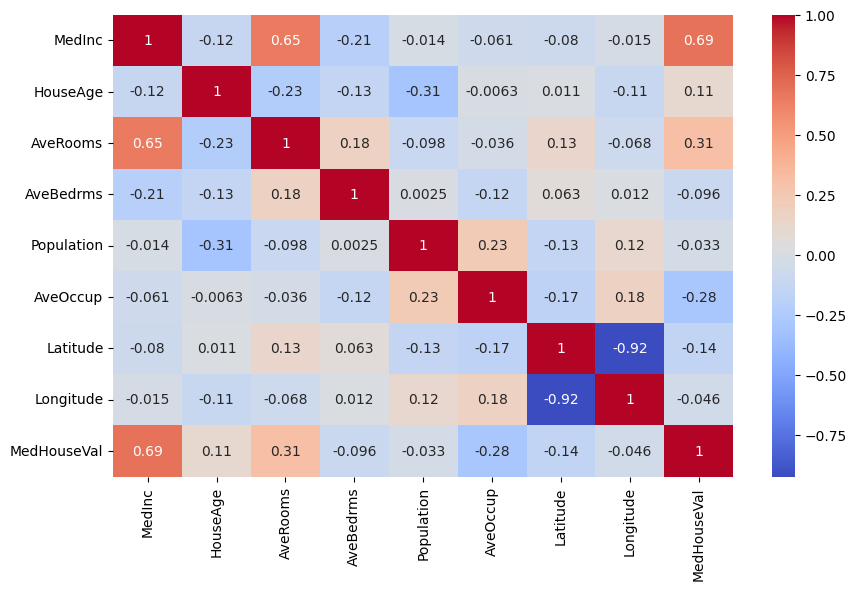

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Insights
- `MedInc` has the strongest positive correlation with `MedHouseVal`
- Several other features have weaker linear correlations with the target.

### `MedHouseVal` Distribution

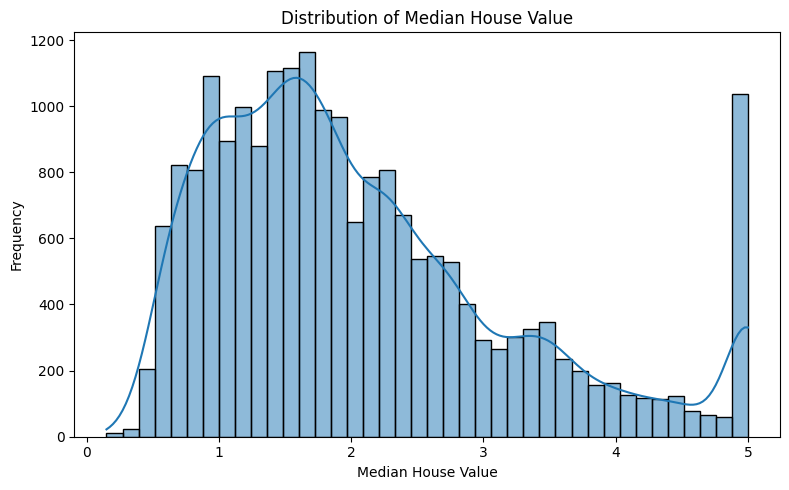

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=40, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

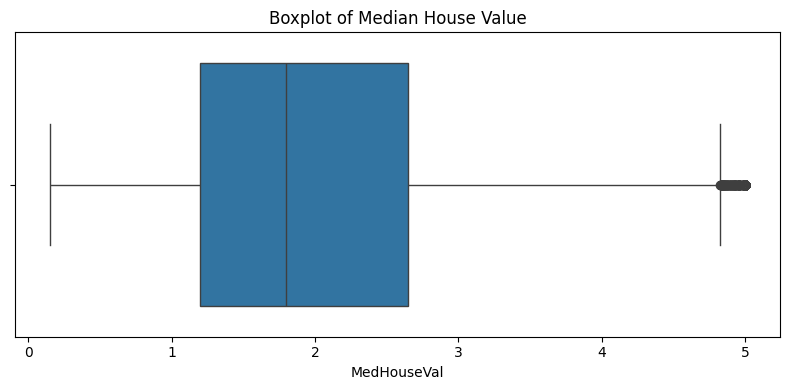

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['MedHouseVal'])
plt.title('Boxplot of Median House Value')
plt.tight_layout()
plt.show()

### Insight
The boxplot confirms the spread of house values and highlights observations at the higher end.

### House Age (`HouseAge`) Distribution

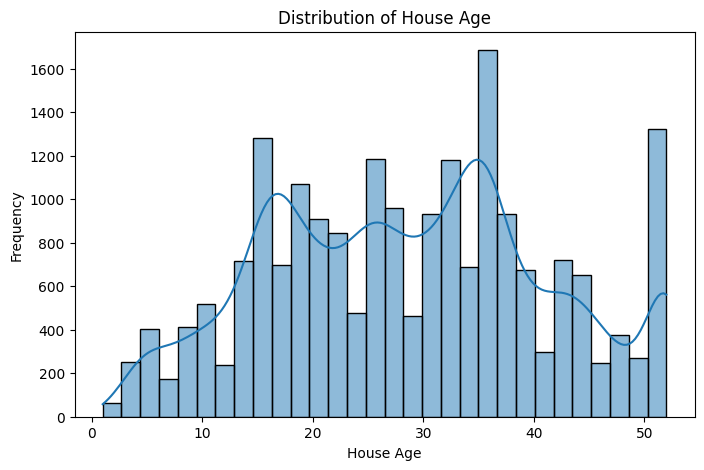

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="HouseAge",
    bins=30,
    kde=True
)

plt.title("Distribution of House Age")
plt.xlabel("House Age")
plt.ylabel("Frequency")

plt.show()

### Median Income (`MedInc`) Distribution

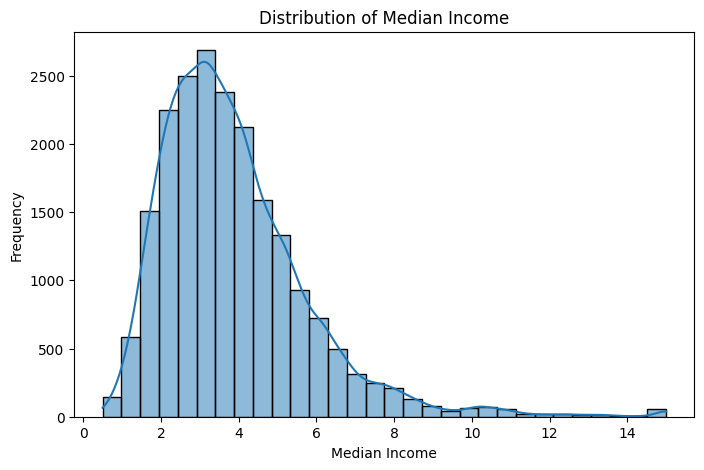

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="MedInc",bins=30,kde=True)

plt.title("Distribution of Median Income")
plt.xlabel("Median Income")
plt.ylabel("Frequency")

plt.show()

### Distribution of All Numerical Features

In [ ]:
df.hist(figsize=(15, 12),bins=30)
plt.show()

### Final EDA Conclusions

#### Main Findings
1. Several variables contain potential outliers, especially `AveRooms`, `AveBedrms`, `Population`, and `AveOccup`.
2. The target `MedHouseVal` is not perfectly normally distributed and has a concentration toward its upper range.
3. `MedInc` has the strongest positive relationship with `MedHouseVal`.
4. Geographic variables (`Latitude` and `Longitude`) may also contain useful information about house values.

## Step 6: Data Preprocessing

### 1. Select Features and Target:

For the Multiple Linear Regression model:

- `X` contains the independent variables (features).
- `y` contains the dependent variable (target).

The target variable is `MedHouseVal`.

In [ ]:
x = df.drop('MedHouseVal' , axis= 1)
y = df['MedHouseVal']

### 2. Train/Test Split:

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y ,test_size= 0.2, random_state=42)

### 3. Numeric Feature Scaling:

In [ ]:
scaler = StandardScaler() 

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
x_train_scaled = pd.DataFrame(
    x_train_scaled, 
    columns= x_train.columns, 
    index = x_train.index
)

x_test_scaled = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

## Step 7: Machine Learning

### 1. Train `Linear Regression`:

In [ ]:
model = LinearRegression() 
model.fit(x_train_scaled,y_train)

### 2. Make predictions:

In [ ]:
y_pred = model.predict(x_test_scaled)

In [ ]:
comparison = pd.DataFrame({
    'Actual Values' : y_test.values, 
    'Predicted Values' : y_pred
})

comparison.head()

### 3. Evaluate Linear Regression model:

To evaluate the performance of the regression model, we use:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between the actual and predicted values. Lower values indicate better performance.
  
- **MSE (Mean Squared Error):** Measures the average squared difference between the actual and predicted values. Lower values indicate better performance, with larger errors receiving more weight.


- **RMSE (Root Mean Squared Error):** Measures the square root of the average squared prediction errors. Lower values indicate better performance and the metric is expressed in the same units as the target variable.

  
- **R² Score:** Measures how much of the variation in the target variable is explained by the model. A value closer to 1 indicates better performance.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

### 4. Actual vs Predicted:

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5 )

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values",fontweight = 'bold') 

plt.tight_layout()
plt.savefig('Actual_Vs_Predicted.jpg')
plt.show()

### 5. Train Ridge Model (L2 Regularization):

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(x_train_scaled, y_train)

y_pred_ridge = ridge.predict(x_test_scaled)

### 6. Evaluate Ridge Model:

In [ ]:
mae_ridge = mean_absolute_error(y_test, y_pred)
mse_ridge = mean_squared_error(y_test, y_pred)
rmse_ridge = np.sqrt(mse)
r2_ridge = r2_score(y_test, y_pred)

print(f"MAE: {mae_ridge:.2f}")
print(f"MSE: {mse_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²: {r2_ridge:.2f}")

#### Insight:
`Linear Regression Model` and `Ridge Model` have the same **MAE**: 0.50, **MSE**: 0.46, **RMSE**: 0.68 and **R²**: 0.65 ,So there in no any change in the model evaluation or improving. 

### 7. Feature Coefficients:
how each feature contributes to the prediction

In [ ]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    "Coefficient",
    ascending=False
)

## Final conclusion

The Multiple Linear Regression model and The Ridge Model achieved an **MAE of 0.50**, **MSE of 0.46**, **RMSE of 0.68**, and an **R² score of 0.65**. This means that the models explains approximately **65% of the variation in house values**, while the predictions have a moderate level of error.

The feature coefficients show that **MedInc (Median Income)** has a strong positive relationship with house values, while **Latitude** and **Longitude** have strong negative coefficients in this model. **HouseAge** and **AveBedrms** also have positive effects, while **AveOccup** and **AveRooms** have negative coefficients.

Overall, the models provide a reasonable baseline for predicting California house prices. However, the remaining unexplained variation suggests that more advanced models, feature engineering, or additional data could potentially improve prediction performance.
